# **Phishing Website Detection using Machine Learning**

## **Data Science in Cyber - Final Project**



**Source:  Phishing Website Detection by Machine Learning Techniques**


### **Introduction:**

Phishing is one of the most common cybersecurity threats. Attackers often build fake websites that look like real ones to trick people into giving away sensitive information like usernames, passwords, or financial details.

In this project, the aim is to recreate and evaluate an existing machine learning method for detecting phishing websites. After that, several machine learning models will be compared using different evaluation metrics to see which performs best.

**Dataset Description:**

The dataset for this project comes from the Phishing Website Detection by Machine Learning Techniques repository.

Phishing URLs were taken from the PhishTank database, and the legitimate URLs were collected from the University of New Brunswick’s URL dataset.

In total, the dataset includes 10,000 URLs:

-5,000 legitimate URLs

-5,000 phishing URLs

For each URL, 17 handcrafted features were extracted. These features are based on the URL structure, domain details, and some characteristics of the website content. They are used to train machine learning models to classify whether a website is phishing or legitimate.

**Data Loading:**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("5.urldata.csv")

print("Dataset Shape:")
print(data.shape)

data.head()

Dataset Shape:
(10000, 18)


,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,graphicriver.net,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,0
1,ecnavi.jp,0,0,1,1,1,0,0,0,0,1,1,1,0,0,1,0,0
2,hubpages.com,0,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0,0
3,extratorrent.cc,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
4,icicibank.com,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0


**Data Understanding:**

In [2]:
print("Dataset Information:")
data.info()

print("\nMissing Values:")
print(data.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Domain         10000 non-null  object
 1   Have_IP        10000 non-null  int64 
 2   Have_At        10000 non-null  int64 
 3   URL_Length     10000 non-null  int64 
 4   URL_Depth      10000 non-null  int64 
 5   Redirection    10000 non-null  int64 
 6   https_Domain   10000 non-null  int64 
 7   TinyURL        10000 non-null  int64 
 8   Prefix/Suffix  10000 non-null  int64 
 9   DNS_Record     10000 non-null  int64 
 10  Web_Traffic    10000 non-null  int64 
 11  Domain_Age     10000 non-null  int64 
 12  Domain_End     10000 non-null  int64 
 13  iFrame         10000 non-null  int64 
 14  Mouse_Over     10000 non-null  int64 
 15  Right_Click    10000 non-null  int64 
 16  Web_Forwards   10000 non-null  int64 
 17  Label          10000 non-null  int64 
dtypes: int

**Interpretation:**

The dataset includes 10,000 samples and 18 columns. Out of these, 17 columns are numerical features, and one column (Domain) contains text.

There are no missing values in any of the features, so no imputation or special handling is needed before training the models.

Overall, the dataset is already clean and ready for exploratory analysis and preprocessing.

# **Exploratory Data Analysis (EDA):**

**Class Distribution Analysis:**

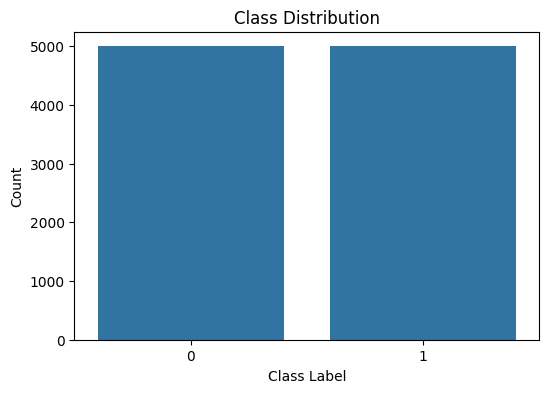

Label
0    5000
1    5000
Name: count, dtype: int64


In [3]:
plt.figure(figsize=(6,4))

sns.countplot(x='Label', data=data)

plt.title("Class Distribution")
plt.xlabel("Class Label")
plt.ylabel("Count")

plt.show()

print(data['Label'].value_counts())

**Interpretation:**

The class distribution in the dataset is perfectly balanced, with 5,000 legitimate URLs and 5,000 phishing URLs.

This balance is helpful for machine learning because it means the models won’t be affected by class imbalance during training or evaluation. As a result, there’s no need to use resampling methods like oversampling or undersampling.

### **Class Imbalance Analysis**

The dataset is perfectly balanced, containing 5,000 phishing websites and 5,000 legitimate websites.

A balanced dataset makes model training and evaluation easier because both classes are equally represented.

However, real-world phishing detection is usually an imbalanced problem, where legitimate websites greatly outnumber phishing websites.

Therefore, the reported performance may be optimistic compared to real deployment, where phishing websites are much less common.

**Correlation Analysis:**

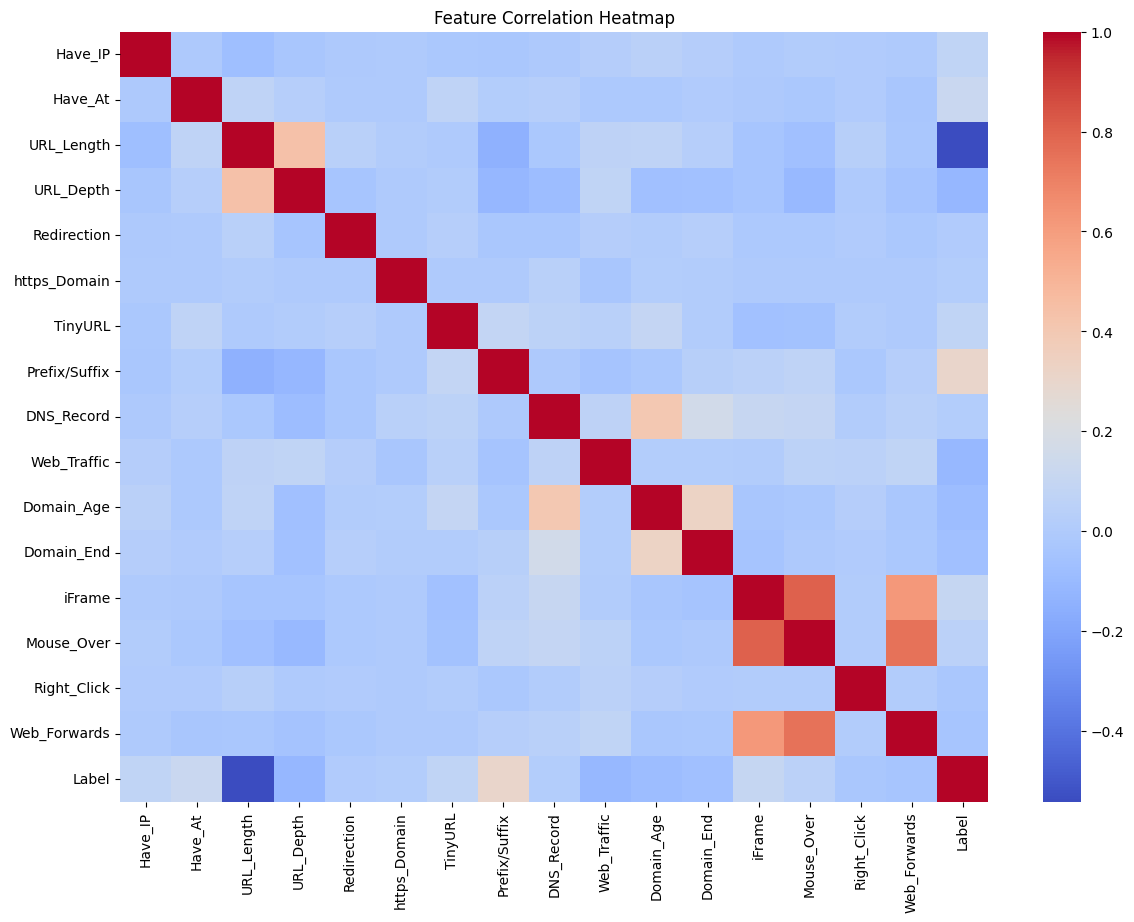

In [4]:
plt.figure(figsize=(14,10))

correlationMatrix = data.drop("Domain", axis=1).corr()

sns.heatmap(
    correlationMatrix,
    annot=False,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

**Interpretation:**

The correlation heatmap shows that most features have only weak relationships with each other, meaning the dataset doesn’t suffer from strong multicollinearity.

Some feature pairs do show moderate positive correlations. For example, URL_Length and URL_Depth are positively related, which makes sense because longer URLs usually have more directory levels.

There is also a noticeable correlation between Domain_Age and Domain_End, since both are tied to domain registration details.

Overall, the features seem to provide different types of information, which is useful for training machine learning models.

**Feature Distributions:**

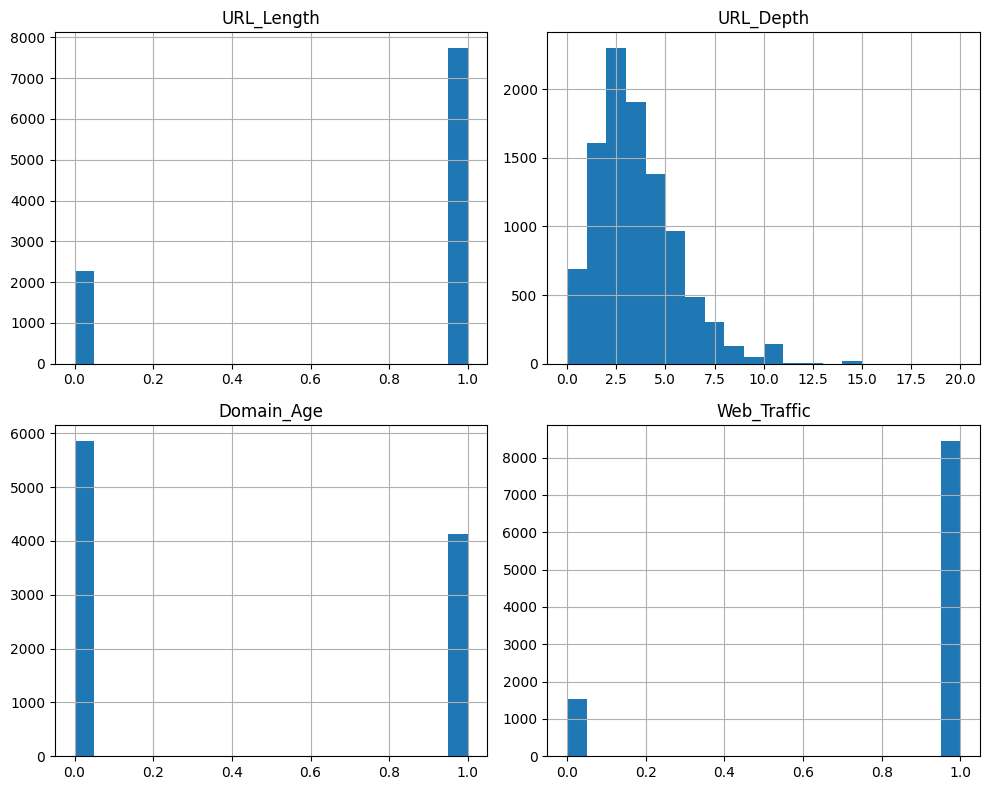

In [5]:
selectedFeatures = [
    "URL_Length",
    "URL_Depth",
    "Domain_Age",
    "Web_Traffic"
]

data[selectedFeatures].hist(
    figsize=(10,8),
    bins=20
)

plt.tight_layout()
plt.show()

**Interpretation:**

The feature distributions show that some variables, like URL_Length, Domain_Age, and Web_Traffic, were turned into binary features during feature engineering.

This means the original author used rule‑based thresholds instead of keeping the continuous values. While this makes the dataset easier to work with, it can also lead to some loss of information.

On the other hand, URL_Depth is still a numerical feature and has a wider range, with most URLs having between 2 and 5 directory levels.

**Feature Correlation with the Target Variable:**

In [6]:
targetCorrelation = correlationMatrix["Label"].sort_values(
    ascending=False
)

print(targetCorrelation)

Label            1.000000
Prefix/Suffix    0.302705
Have_At          0.118419
iFrame           0.098446
Have_IP          0.074367
TinyURL          0.072921
Mouse_Over       0.051338
DNS_Record       0.015943
https_Domain     0.014144
Redirection      0.002600
Right_Click     -0.026467
Web_Forwards    -0.041376
Domain_End      -0.068556
Domain_Age      -0.085077
Web_Traffic     -0.108793
URL_Depth       -0.119707
URL_Length      -0.541287
Name: Label, dtype: float64


**Interpretation:**

The strongest correlation with the target variable is seen in URL_Length (-0.541), which suggests that URL length is one of the most useful features in the dataset.

Prefix/Suffix also has a noticeable positive correlation (0.303), meaning that domains containing hyphens are more likely to be linked to phishing websites.

Most of the other features show only weak correlations with the target. This means that phishing detection can’t rely on just one feature — it works better when multiple features are combined through machine learning models.

**Duplicate Rows Analysis:**

Before training the models, it is important to verify whether the dataset contains duplicate samples. Duplicate rows may bias the learning process and affect the evaluation results.

In [7]:
duplicateRows = data.duplicated().sum()

print("Duplicate Rows:", duplicateRows)

Duplicate Rows: 5626


In [8]:
print("Duplicate domains:", data["Domain"].duplicated().sum())

Duplicate domains: 6447


**Example of Duplicate Records:**

To better understand the duplicated samples, one of the duplicated domains is displayed below.

In [9]:
data[data["Domain"] == data["Domain"].value_counts().idxmax()]

,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
27,torcache.net,0,0,1,2,0,0,0,0,0,0,1,1,0,0,1,0,0
70,torcache.net,0,0,1,2,0,0,0,0,0,0,1,1,0,0,1,0,0
73,torcache.net,0,0,1,2,0,0,0,0,0,0,1,1,0,0,1,0,0
99,torcache.net,0,0,1,2,0,0,0,0,0,0,1,1,0,0,1,0,0
100,torcache.net,0,0,1,2,0,0,0,0,0,0,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4872,torcache.net,0,0,1,2,0,0,0,0,0,0,1,1,0,0,1,0,0
4904,torcache.net,0,0,1,2,0,0,0,0,0,0,1,1,0,0,1,0,0
4915,torcache.net,0,0,1,2,0,0,0,0,0,0,1,1,0,0,1,0,0
4958,torcache.net,0,0,1,2,0,0,0,0,0,0,1,1,0,0,1,0,0


In [ ]:
duplicatePercentage = data.duplicated().mean() * 100

print(f"Duplicate Samples: {duplicatePercentage:.2f}%")

Duplicate Samples: 56.26%


**Interpretation:**

The duplicate check found 5,626 duplicated rows, representing approximately 56% of the dataset.

Further inspection shows that many duplicated records are completely identical, including the domain name, handcrafted features, and class label.

Since this project aims to reproduce the original study, the duplicated samples were intentionally kept to preserve the original dataset and ensure a fair comparison with the published results.

However, this represents an important limitation of the dataset. Because identical samples appear many times, the reported evaluation metrics may be slightly optimistic compared with a dataset containing only unique websites. This limitation should be considered when interpreting the experimental results.

**Summary Statistics:**

The table below summarizes the main statistical properties of the numerical features, including the mean, standard deviation, quartiles, and value ranges.

In [10]:
summaryStatistics = data.describe().T

summaryStatistics

,count,mean,std,min,25%,50%,75%,max
Have_IP,10000.0,0.0055,0.073961,0.0,0.0,0.0,0.0,1.0
Have_At,10000.0,0.0226,0.148632,0.0,0.0,0.0,0.0,1.0
URL_Length,10000.0,0.7734,0.418653,0.0,1.0,1.0,1.0,1.0
URL_Depth,10000.0,3.0720,2.128631,0.0,2.0,3.0,4.0,20.0
Redirection,10000.0,0.0135,0.115408,0.0,0.0,0.0,0.0,1.0
https_Domain,10000.0,0.0002,0.014141,0.0,0.0,0.0,0.0,1.0
TinyURL,10000.0,0.0903,0.286625,0.0,0.0,0.0,0.0,1.0
Prefix/Suffix,10000.0,0.0932,0.290727,0.0,0.0,0.0,0.0,1.0
DNS_Record,10000.0,0.1008,0.301079,0.0,0.0,0.0,0.0,1.0
Web_Traffic,10000.0,0.8457,0.361254,0.0,1.0,1.0,1.0,1.0


**Interpretation:**

The summary statistics show that the dataset contains a mixture of binary and numerical features.

Most features are binary, with values of 0 or 1. This is expected because many of the handcrafted features represent the presence or absence of suspicious website characteristics.

In contrast, URL_Depth is a numerical feature with a wider range (0–20), indicating different levels of URL complexity. It is also one of the few features with noticeable variation.

The target variable (Label) has a mean of 0.5, confirming that the dataset is perfectly balanced, with an equal number of phishing and legitimate websites.

**Outlier Analysis:**

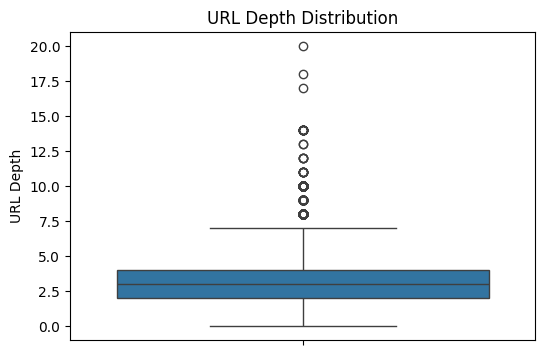

In [11]:
plt.figure(figsize=(6,4))

sns.boxplot(y=data["URL_Depth"])

plt.title("URL Depth Distribution")

plt.ylabel("URL Depth")

plt.show()

**Interpretation:**

The boxplot shows that most URLs have a depth between 2 and 4 directory levels.

A small number of URLs have much larger depths, reaching up to 20 levels, and appear as outliers. Such URLs may represent unusually complex website structures, which can sometimes be associated with phishing websites.

The outliers were not removed because tree-based models are generally robust to extreme values, and preserving the original dataset allows a fair comparison with the original study.

**Data Preprocessing:**

In [12]:
X = data.drop(["Domain","Label"], axis=1)

y = data["Label"]

print("Features Shape:")
print(X.shape)

print("\nLabels Shape:")
print(y.shape)

Features Shape:
(10000, 16)

Labels Shape:
(10000,)


The Domain column was removed because it contains text and can’t be directly used by the machine learning models.

The remaining features were saved in X, and the target variable (Label) was stored in y.

**Train/Test Split:**

In [13]:
from sklearn.model_selection import train_test_split

XTrain, XTest, yTrain, yTest = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set Shape:")
print(XTrain.shape)

print("\nTest Set Shape:")
print(XTest.shape)

Training Set Shape:
(8000, 16)

Test Set Shape:
(2000, 16)


**Interpretation:**

The dataset was split into training and testing sets using an 80%-20% ratio.

Stratified sampling was applied to make sure the class balance stayed the same in both sets.

**Training \Test Labels Distribution:**

In [14]:
print("Training Labels Distribution:")
print(yTrain.value_counts())

print("\nTest Labels Distribution:")
print(yTest.value_counts())

Training Labels Distribution:
Label
0    4000
1    4000
Name: count, dtype: int64

Test Labels Distribution:
Label
0    1000
1    1000
Name: count, dtype: int64


**Interpretation:**

The dataset was split into training and testing sets using an 80%–20% ratio. This resulted in 8,000 samples for training and 2,000 samples for testing.

Stratified sampling was used to keep the same class distribution in both sets, so phishing and legitimate URLs are represented equally in the training and test data.


**Feature Importance Analysis:**

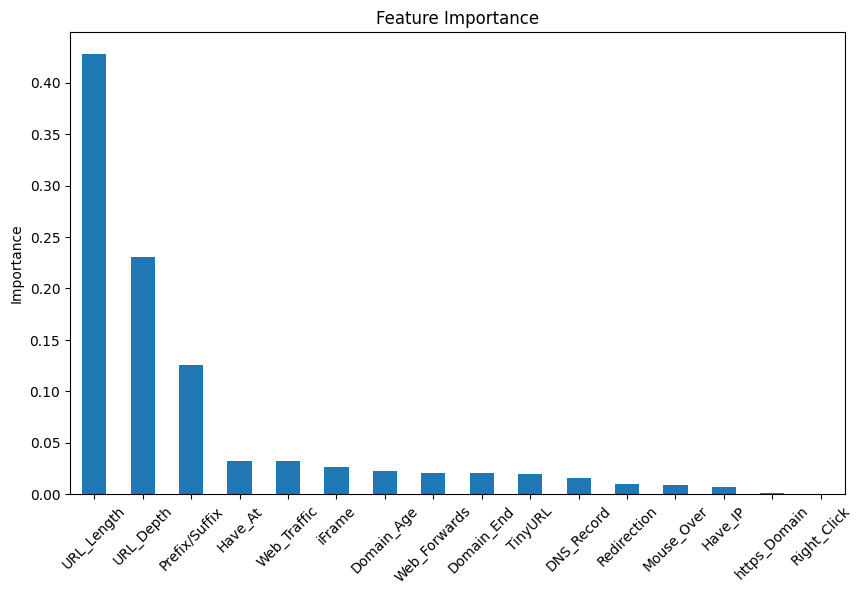

,0
URL_Length,0.427835
URL_Depth,0.230449
Prefix/Suffix,0.125578
Have_At,0.032587
Web_Traffic,0.031908
iFrame,0.025899
Domain_Age,0.022634
Web_Forwards,0.021028
Domain_End,0.020690
TinyURL,0.019595


In [15]:
from sklearn.ensemble import RandomForestClassifier

featureModel = RandomForestClassifier(
    random_state=42
)

featureModel.fit(X, y)

featureImportance = pd.Series(
    featureModel.feature_importances_,
    index=X.columns
).sort_values(
    ascending=False
)

plt.figure(figsize=(10,6))

featureImportance.plot(
    kind="bar"
)

plt.ylabel("Importance")

plt.title("Feature Importance")

plt.xticks(rotation=45)

plt.show()

featureImportance

**Interpretation:**

The feature importance analysis shows that URL_Length is the most influential feature for phishing detection, followed by URL_Depth and Prefix/Suffix.

This suggests that the structure of the URL is one of the strongest indicators for distinguishing phishing websites from legitimate ones. Phishing URLs are often longer, contain more directory levels, or use suspicious prefixes and suffixes to imitate legitimate websites.

Several other features, such as Web_Traffic, iFrame, Domain_Age, and TinyURL, also contribute to the prediction but with much smaller importance values.

Features such as https_Domain and Right_Click have almost no contribution in this dataset, indicating that they provide little additional information for the Random Forest model.

### **Feature Engineering Analysis**

Most of the features were manually engineered based on domain knowledge rather than extracted automatically from raw URLs.

This makes the dataset relatively easy for tree-based models to learn, but it may also limit the ability to generalize to new phishing techniques that use different URL patterns.

**Feature Groups:**

In [16]:
urlFeatures = [
    "Have_IP",
    "Have_At",
    "URL_Length",
    "URL_Depth",
    "Prefix/Suffix"
]

domainFeatures = [
    "DNS_Record",
    "Web_Traffic",
    "Domain_Age",
    "Domain_End"
]

websiteFeatures = [
    "Redirection",
    "https_Domain",
    "TinyURL",
    "iFrame",
    "Mouse_Over",
    "Right_Click",
    "Web_Forwards"
]

print("URL Features:", len(urlFeatures))
print(urlFeatures)

print()

print("Domain Features:", len(domainFeatures))
print(domainFeatures)

print()

print("Website Features:", len(websiteFeatures))
print(websiteFeatures)

URL Features: 5
['Have_IP', 'Have_At', 'URL_Length', 'URL_Depth', 'Prefix/Suffix']

Domain Features: 4
['DNS_Record', 'Web_Traffic', 'Domain_Age', 'Domain_End']

Website Features: 7
['Redirection', 'https_Domain', 'TinyURL', 'iFrame', 'Mouse_Over', 'Right_Click', 'Web_Forwards']


**Interpretation:**

The handcrafted features can be grouped into three main categories.

The URL features describe the structure of the URL itself, such as its length, depth, and suspicious characters.

The domain features describe properties of the domain, including its registration information, DNS records, and web traffic.

The website features describe the behavior of the webpage, such as redirections, iFrames, TinyURL usage, and browser interactions.

Using features from different categories helps the machine learning models detect phishing websites by combining information from the URL, the domain, and the webpage behavior.

**Binary vs Numerical Features:**

In [17]:
binaryFeatures = []
numericalFeatures = []

for column in X.columns:

    uniqueValues = data[column].nunique()

    if uniqueValues <= 2:
        binaryFeatures.append(column)
    else:
        numericalFeatures.append(column)

print("Binary Features:", len(binaryFeatures))
print(binaryFeatures)

print()

print("Numerical Features:", len(numericalFeatures))
print(numericalFeatures)

Binary Features: 15
['Have_IP', 'Have_At', 'URL_Length', 'Redirection', 'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record', 'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over', 'Right_Click', 'Web_Forwards']

Numerical Features: 1
['URL_Depth']


**Interpretation:**

The dataset contains 15 binary features and only one numerical feature (URL_Depth).

Most features were transformed into binary variables during feature engineering, allowing the models to simply determine whether a suspicious characteristic exists or not.

This representation simplifies the learning process and is especially suitable for tree-based models. However, converting continuous information into binary values may also remove useful details that could improve the performance of some machine learning models.

The only continuous feature is URL_Depth, which preserves the actual number of directory levels in the URL and therefore contains richer information than the binary features.

## **Logistic Regression:**

**Description:**

Logistic regression is one of the most widely used classification algorithms. It serves as a robust baseline model and provides an interpretable approach to binary classification problems such as phishing website detection.

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logisticModel = LogisticRegression(max_iter=1000)

logisticModel.fit(XTrain, yTrain)

logisticPredictions = logisticModel.predict(XTest)

logisticAccuracy = accuracy_score(
    yTest,
    logisticPredictions
)

print("Logistic Regression Accuracy:")
print(logisticAccuracy)

Logistic Regression Accuracy:
0.7975


**Interpretation:**

The Logistic Regression model achieved an accuracy of 79.75% on the test set.

This model provides a simple baseline for comparison, but its accuracy is lower than that of the more advanced models used in the original project. This indicates that phishing website detection may require more complex models that can capture non-linear patterns in the data.


**Evaluation Metrics:**

In [21]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    matthews_corrcoef
)
logisticPrecision = precision_score(
    yTest,
    logisticPredictions
)

logisticRecall = recall_score(
    yTest,
    logisticPredictions
)

logisticF1 = f1_score(
    yTest,
    logisticPredictions
)
logisticF2 = fbeta_score(
    yTest,
    logisticPredictions,
    beta=2
)

logisticMCC = matthews_corrcoef(
    yTest,
    logisticPredictions
)

print("Accuracy :", round(logisticAccuracy,4))
print("Precision:", round(logisticPrecision,4))
print("Recall   :", round(logisticRecall,4))
print("F1 Score :", round(logisticF1,4))
print("F2 Score :", round(logisticF2,4))
print("MCC      :", round(logisticMCC,4))

Accuracy : 0.7975
Precision: 0.9268
Recall   : 0.646
F1 Score : 0.7613
F2 Score : 0.6877
MCC      : 0.6244


**Interpretation:**

The Logistic Regression model achieved an accuracy of **79.75%**.

The precision is high (**92.68%**), which means that most websites predicted as phishing were actually phishing websites. However, the recall is lower (**64.60%**), meaning that the model missed many phishing websites.

Overall, Logistic Regression works as a good baseline model, but it may not be the best choice for phishing detection since detecting as many phishing websites as possible is very important.


**Confusion Matrix:**

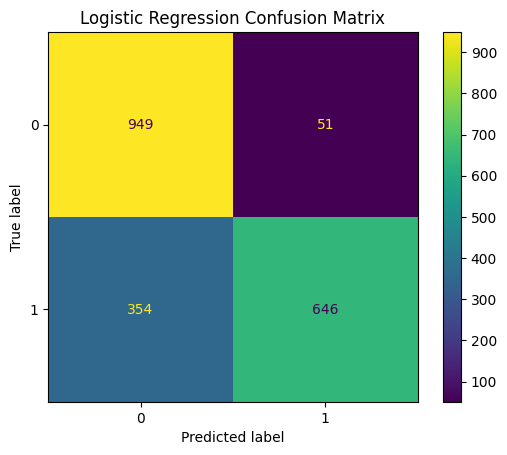

In [22]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

confusionMatrix = confusion_matrix(
    yTest,
    logisticPredictions
)

ConfusionMatrixDisplay(
    confusion_matrix=confusionMatrix
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

**Interpretation:**

The confusion matrix shows that the Logistic Regression model correctly classified 949 legitimate websites and 646 phishing websites.

It incorrectly classified only 51 legitimate websites as phishing, which explains the high precision. However, it missed 354 phishing websites, leading to a lower recall.

Overall, the model makes few false alarms, but it misses many phishing websites. This means it is not the best model when the goal is to detect as many phishing attacks as possible.

## **Decision Tree**

**Description :**

Decision Tree is a supervised machine learning algorithm that classifies data by learning a series of decision rules from the training dataset. It is easy to interpret and can capture non-linear relationships between the features.

**Training:**

In [23]:
from sklearn.tree import DecisionTreeClassifier

decisionTreeModel = DecisionTreeClassifier(
    random_state=42
)

decisionTreeModel.fit(
    XTrain,
    yTrain
)

decisionTreePredictions = decisionTreeModel.predict(
    XTest
)

decisionTreeAccuracy = accuracy_score(
    yTest,
    decisionTreePredictions
)

print("Decision Tree Accuracy:")
print(decisionTreeAccuracy)

Decision Tree Accuracy:
0.865


### Interpretation

The Decision Tree model achieved an accuracy of **86.50%** on the test set.

Compared to Logistic Regression, the Decision Tree gave better accuracy. This shows that it can learn more complex patterns in the data, making it a better model for phishing website classification.


**Evaluation Metrics:**

In [25]:
decisionTreePrecision = precision_score(
    yTest,
    decisionTreePredictions
)

decisionTreeRecall = recall_score(
    yTest,
    decisionTreePredictions
)

decisionTreeF1 = f1_score(
    yTest,
    decisionTreePredictions
)
decisionTreeF2 = fbeta_score(
    yTest,
    decisionTreePredictions,
    beta=2
)

decisionTreeMCC = matthews_corrcoef(
    yTest,
    decisionTreePredictions
)

print("Accuracy :", round(decisionTreeAccuracy,4))
print("Precision:", round(decisionTreePrecision,4))
print("Recall   :", round(decisionTreeRecall,4))
print("F1 Score :", round(decisionTreeF1,4))
print("F2 Score :", round(decisionTreeF2,4))
print("MCC      :", round(decisionTreeMCC,4))

Accuracy : 0.865
Precision: 0.9254
Recall   : 0.794
F1 Score : 0.8547
F2 Score : 0.8172
MCC      : 0.7375


### Interpretation

The Decision Tree model achieved an accuracy of **86.50%**, which is better than the Logistic Regression model.

The precision is still very high (**92.54%**), so most websites predicted as phishing were actually phishing websites. The recall also increased to **79.40%**, which means the model detected more phishing websites than Logistic Regression.

The higher F1-score (**85.47%**) shows that the model has a better balance between precision and recall, making it a better choice for this dataset.


**Confusion Matrix:**

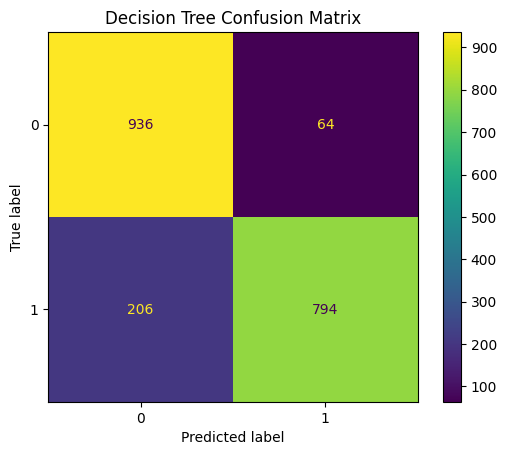

In [26]:
decisionTreeMatrix = confusion_matrix(
    yTest,
    decisionTreePredictions
)

ConfusionMatrixDisplay(
    confusion_matrix=decisionTreeMatrix
).plot()

plt.title("Decision Tree Confusion Matrix")
plt.show()

### Interpretation

The confusion matrix shows that the Decision Tree model correctly classified **936** legitimate websites and **794** phishing websites.

Compared to Logistic Regression, the Decision Tree detected more phishing websites and missed fewer phishing attacks. Although it made a few more false positives, the improvement in phishing detection is much larger.

Overall, the Decision Tree gives a better balance between precision and recall, making it a better model for this dataset.


## **Random Forest**

 **Description :**

Random Forest is a machine learning model that builds many decision trees and combines their predictions. This usually gives better accuracy and helps reduce overfitting compared to using a single Decision Tree.


**Training:**

In [27]:
from sklearn.ensemble import RandomForestClassifier

randomForestModel = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

randomForestModel.fit(
    XTrain,
    yTrain
)

randomForestPredictions = randomForestModel.predict(
    XTest
)

randomForestAccuracy = accuracy_score(
    yTest,
    randomForestPredictions
)

print("Random Forest Accuracy:")
print(randomForestAccuracy)

Random Forest Accuracy:
0.867


### Interpretation

The Random Forest model achieved an accuracy of **86.70%** on the test set.

It achieved the highest accuracy among all the models. Using multiple decision trees helped the model perform slightly better than a single Decision Tree.


**Evaluation Metrics:**

In [28]:
randomForestPrecision = precision_score(
    yTest,
    randomForestPredictions
)

randomForestRecall = recall_score(
    yTest,
    randomForestPredictions
)

randomForestF1 = f1_score(
    yTest,
    randomForestPredictions
)
randomForestF2 = fbeta_score(
    yTest,
    randomForestPredictions,
    beta=2
)

randomForestMCC = matthews_corrcoef(
    yTest,
    randomForestPredictions
)

print("F2 Score :", round(randomForestF2,4))
print("MCC      :", round(randomForestMCC,4))

print("Accuracy :", round(randomForestAccuracy,4))
print("Precision:", round(randomForestPrecision,4))
print("Recall   :", round(randomForestRecall,4))
print("F1 Score :", round(randomForestF1,4))

F2 Score : 0.8213
MCC      : 0.7409
Accuracy : 0.867
Precision: 0.9248
Recall   : 0.799
F1 Score : 0.8573


### Interpretation

The Random Forest model achieved the highest accuracy (**86.70%**) among all the models.

It also had the highest recall (**79.90%**) and F1-score (**85.73%**), showing a good balance between detecting phishing websites and making correct predictions.

Although its precision is slightly lower than Logistic Regression, the difference is very small. Overall, Random Forest gave the best performance and was the best model for this dataset.


**Confusion Matrix:**

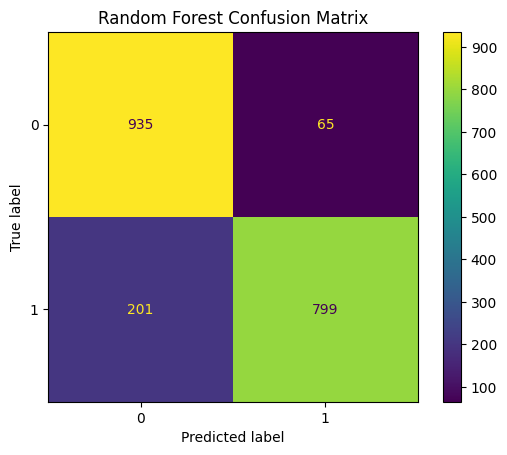

In [29]:
randomForestMatrix = confusion_matrix(
    yTest,
    randomForestPredictions
)

ConfusionMatrixDisplay(
    confusion_matrix=randomForestMatrix
).plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

### Interpretation

The confusion matrix shows that the Random Forest model correctly classified **935** legitimate websites and **799** phishing websites.

It incorrectly classified **65** legitimate websites as phishing and missed **201** phishing websites.

Compared to the other models, Random Forest detected more phishing websites while still keeping high precision. Overall, it gave the best balance between detecting phishing websites and reducing false alarms.


## **Support Vector Machine (SVM)**

Support Vector Machine (SVM) is a machine learning model that separates classes by finding the optimal decision boundary. It is effective for classification tasks and can model non-linear relationships using kernel functions.

**Training:**

In [30]:
from sklearn.svm import SVC

svmModel = SVC(
    kernel="rbf",
    random_state=42
)

svmModel.fit(
    XTrain,
    yTrain
)

svmPredictions = svmModel.predict(
    XTest
)

svmAccuracy = accuracy_score(
    yTest,
    svmPredictions
)

print("SVM Accuracy:")
print(svmAccuracy)

SVM Accuracy:
0.815


The Support Vector Machine achieved an accuracy of 81.50% on the test set.

Although its accuracy is reasonable, it performed worse than Decision Tree and Random Forest on this dataset.

**Evaluation Metrics:**

In [31]:
svmPrecision = precision_score(
    yTest,
    svmPredictions
)

svmRecall = recall_score(
    yTest,
    svmPredictions
)

svmF1 = f1_score(
    yTest,
    svmPredictions
)
svmF2 = fbeta_score(
    yTest,
    svmPredictions,
    beta=2
)

svmMCC = matthews_corrcoef(
    yTest,
    svmPredictions
)

print("F2 Score :", round(svmF2,4))
print("MCC      :", round(svmMCC,4))

print("Accuracy :", round(svmAccuracy,4))
print("Precision:", round(svmPrecision,4))
print("Recall   :", round(svmRecall,4))
print("F1 Score :", round(svmF1,4))

F2 Score : 0.6982
MCC      : 0.6659
Accuracy : 0.815
Precision: 0.966
Recall   : 0.653
F1 Score : 0.7792


The SVM model achieved an accuracy of 81.50%.

It achieved a very high precision (96.60%), meaning that most websites predicted as phishing were indeed phishing.

However, the recall was only 65.30%, meaning that many phishing websites were missed.

Overall, SVM is conservative and produces few false alarms, but it is less effective at detecting all phishing websites.

**Confusion Matrix:**

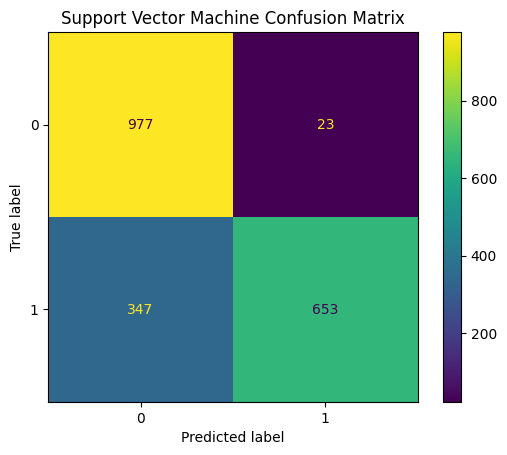

In [32]:
svmMatrix = confusion_matrix(
    yTest,
    svmPredictions
)

ConfusionMatrixDisplay(
    confusion_matrix=svmMatrix
).plot()

plt.title("Support Vector Machine Confusion Matrix")
plt.show()

The confusion matrix shows that the SVM model correctly classified 977 legitimate websites and 653 phishing websites.

It incorrectly classified 23 legitimate websites as phishing and missed 347 phishing websites.

Compared to the other models, SVM produced very few False Positives but a relatively high number of False Negatives.

This indicates that the model is very precise but less suitable for phishing detection, where detecting malicious websites is more important than avoiding false alarms.

## **Multilayer Perceptron:**

Multilayer Perceptron (MLP) is a neural network model that learns complex patterns using multiple layers of neurons. It can capture non-linear relationships between the input features and the target class.

**Training:**

In [33]:
from sklearn.neural_network import MLPClassifier

mlpModel = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=500,
    random_state=42
)

mlpModel.fit(
    XTrain,
    yTrain
)

mlpPredictions = mlpModel.predict(
    XTest
)

mlpAccuracy = accuracy_score(
    yTest,
    mlpPredictions
)

print("MLP Accuracy:")
print(round(mlpAccuracy,4))

MLP Accuracy:
0.855


The Multilayer Perceptron achieved an accuracy of 85.50% on the test set.

Its performance is better than Decision Tree and Support Vector Machine, showing that the neural network was able to learn more complex patterns in the data.

However, it still performed slightly worse than Random Forest.

**Evaluation Metrics:**

In [34]:
mlpPrecision = precision_score(
    yTest,
    mlpPredictions
)

mlpRecall = recall_score(
    yTest,
    mlpPredictions
)

mlpF1 = f1_score(
    yTest,
    mlpPredictions
)
mlpF2 = fbeta_score(
    yTest,
    mlpPredictions,
    beta=2
)

mlpMCC = matthews_corrcoef(
    yTest,
    mlpPredictions
)

print("F2 Score :", round(mlpF2,4))
print("MCC      :", round(mlpMCC,4))

print("Accuracy :", round(mlpAccuracy,4))
print("Precision:", round(mlpPrecision,4))
print("Recall   :", round(mlpRecall,4))
print("F1 Score :", round(mlpF1,4))

F2 Score : 0.8242
MCC      : 0.713
Accuracy : 0.855
Precision: 0.891
Recall   : 0.809
F1 Score : 0.848


The MLP model achieved an accuracy of 85.50%.

It achieved a precision of 89.10%, meaning that most websites predicted as phishing were correctly classified.

The recall reached 80.90%, showing that the model detected most phishing websites while missing relatively few.

Overall, MLP provides a good balance between precision and recall, making it one of the strongest models in this project, although it still performed slightly worse than Random Forest.

**Confusion Matrix:**

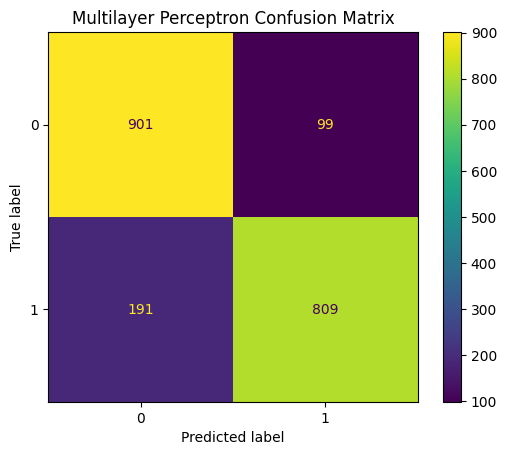

In [35]:
mlpMatrix = confusion_matrix(
    yTest,
    mlpPredictions
)

ConfusionMatrixDisplay(
    confusion_matrix=mlpMatrix
).plot()

plt.title("Multilayer Perceptron Confusion Matrix")
plt.show()

The confusion matrix shows that the MLP model correctly classified 901 legitimate websites and 809 phishing websites.

It incorrectly classified 99 legitimate websites as phishing and missed 191 phishing websites.

Compared to Decision Tree and Support Vector Machine, MLP detected more phishing websites while maintaining high precision. However, it still performed slightly worse than Random Forest, which achieved the best overall balance between false positives and false negatives.

## **XGBoost:**

XGBoost (Extreme Gradient Boosting) is an ensemble learning algorithm that builds many decision trees sequentially. Each new tree focuses on correcting the errors made by the previous trees, leading to strong predictive performance.

**Training:**

In [36]:
from xgboost import XGBClassifier

xgboostModel = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgboostModel.fit(
    XTrain,
    yTrain
)

xgboostPredictions = xgboostModel.predict(
    XTest
)

xgboostAccuracy = accuracy_score(
    yTest,
    xgboostPredictions
)

print("XGBoost Accuracy:")
print(round(xgboostAccuracy,4))

XGBoost Accuracy:
0.8705


The XGBoost model achieved an accuracy of 87.05% on the test set.

It achieved the highest accuracy among all the evaluated models, showing that gradient boosting is highly effective for this phishing website classification task.

**Evaluation Metrics:**

In [37]:
xgboostPrecision = precision_score(
    yTest,
    xgboostPredictions
)

xgboostRecall = recall_score(
    yTest,
    xgboostPredictions
)

xgboostF1 = f1_score(
    yTest,
    xgboostPredictions
)
xgboostF2 = fbeta_score(
    yTest,
    xgboostPredictions,
    beta=2
)

xgboostMCC = matthews_corrcoef(
    yTest,
    xgboostPredictions
)

print("F2 Score :", round(xgboostF2,4))
print("MCC      :", round(xgboostMCC,4))

print("Accuracy :", round(xgboostAccuracy,4))
print("Precision:", round(xgboostPrecision,4))
print("Recall   :", round(xgboostRecall,4))
print("F1 Score :", round(xgboostF1,4))

F2 Score : 0.8287
MCC      : 0.7469
Accuracy : 0.8705
Precision: 0.9234
Recall   : 0.808
F1 Score : 0.8619


The XGBoost model achieved the highest accuracy (87.05%) among all the evaluated models.

It also achieved the highest F1-score (86.19%), showing the best overall balance between precision and recall.

Its precision (92.34%) remained very high, while the recall (80.80%) shows that the model detected most phishing websites with relatively few missed cases.

Overall, XGBoost provided the best performance for this phishing website detection task.

**Confusion Matrix:**

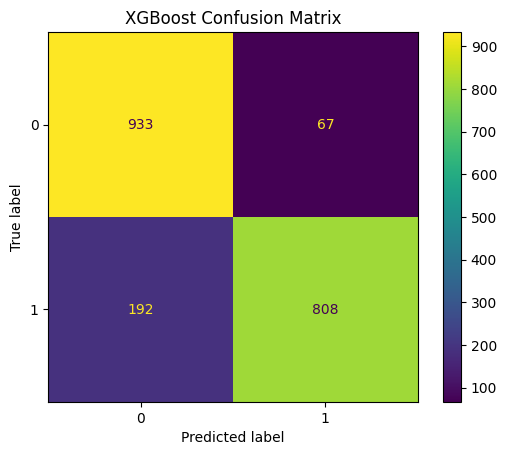

In [38]:
xgboostMatrix = confusion_matrix(
    yTest,
    xgboostPredictions
)

ConfusionMatrixDisplay(
    confusion_matrix=xgboostMatrix
).plot()

plt.title("XGBoost Confusion Matrix")
plt.show()

The confusion matrix shows that the XGBoost model correctly classified 933 legitimate websites and 808 phishing websites.

It incorrectly classified 67 legitimate websites as phishing and missed 192 phishing websites.

Compared to the other models, XGBoost achieved the best overall performance, with the highest accuracy and F1-score while maintaining high precision and recall.

Overall, it provided the best balance between detecting phishing websites and reducing false alarms.

In [39]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score

logisticScores = logisticModel.predict_proba(XTest)[:,1]
decisionTreeScores = decisionTreeModel.predict_proba(XTest)[:,1]
randomForestScores = randomForestModel.predict_proba(XTest)[:,1]
svmScores = svmModel.decision_function(XTest)
mlpScores = mlpModel.predict_proba(XTest)[:,1]
xgboostScores = xgboostModel.predict_proba(XTest)[:,1]

logisticRocAuc = roc_auc_score(yTest, logisticScores)
decisionTreeRocAuc = roc_auc_score(yTest, decisionTreeScores)
randomForestRocAuc = roc_auc_score(yTest, randomForestScores)
svmRocAuc = roc_auc_score(yTest, svmScores)
mlpRocAuc = roc_auc_score(yTest, mlpScores)
xgboostRocAuc = roc_auc_score(yTest, xgboostScores)

logisticPrAuc = average_precision_score(yTest, logisticScores)
decisionTreePrAuc = average_precision_score(yTest, decisionTreeScores)
randomForestPrAuc = average_precision_score(yTest, randomForestScores)
svmPrAuc = average_precision_score(yTest, svmScores)
mlpPrAuc = average_precision_score(yTest, mlpScores)
xgboostPrAuc = average_precision_score(yTest, xgboostScores)

print("ROC-AUC and PR-AUC were calculated successfully.")

ROC-AUC and PR-AUC were calculated successfully.


## **Comparison Between Models**

**Comparison Table:**

**Description :**

The table below compares the performance of all the trained models. It shows the main evaluation metrics: Accuracy, Precision, Recall, and F1-score.


In [40]:
comparisonTable = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Support Vector Machine",
        "Multilayer Perceptron",
        "XGBoost"
    ],

    "Accuracy":[
        logisticAccuracy,
        decisionTreeAccuracy,
        randomForestAccuracy,
        svmAccuracy,
        mlpAccuracy,
        xgboostAccuracy
    ],

    "Precision":[
        logisticPrecision,
        decisionTreePrecision,
        randomForestPrecision,
        svmPrecision,
        mlpPrecision,
        xgboostPrecision
    ],

    "Recall":[
        logisticRecall,
        decisionTreeRecall,
        randomForestRecall,
        svmRecall,
        mlpRecall,
        xgboostRecall
    ],

    "F1 Score":[
        logisticF1,
        decisionTreeF1,
        randomForestF1,
        svmF1,
        mlpF1,
        xgboostF1
    ],

    "F2 Score":[
        logisticF2,
        decisionTreeF2,
        randomForestF2,
        svmF2,
        mlpF2,
        xgboostF2
    ],

    "MCC":[
        logisticMCC,
        decisionTreeMCC,
        randomForestMCC,
        svmMCC,
        mlpMCC,
        xgboostMCC
    ],

    "ROC-AUC":[
        logisticRocAuc,
        decisionTreeRocAuc,
        randomForestRocAuc,
        svmRocAuc,
        mlpRocAuc,
        xgboostRocAuc
    ],

    "PR-AUC":[
        logisticPrAuc,
        decisionTreePrAuc,
        randomForestPrAuc,
        svmPrAuc,
        mlpPrAuc,
        xgboostPrAuc
    ]

})

comparisonTable = comparisonTable.round(4)

comparisonTable = comparisonTable.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

comparisonTable

,Model,Accuracy,Precision,Recall,F1 Score,F2 Score,MCC,ROC-AUC,PR-AUC
0,XGBoost,0.8705,0.9234,0.808,0.8619,0.8287,0.7469,0.9255,0.9431
1,Random Forest,0.8670,0.9248,0.799,0.8573,0.8213,0.7409,0.9257,0.9428
2,Decision Tree,0.8650,0.9254,0.794,0.8547,0.8172,0.7375,0.9168,0.9356
3,Multilayer Perceptron,0.8550,0.8910,0.809,0.8480,0.8242,0.7130,0.9208,0.9395
4,Support Vector Machine,0.8150,0.9660,0.653,0.7792,0.6982,0.6659,0.8916,0.9180
5,Logistic Regression,0.7975,0.9268,0.646,0.7613,0.6877,0.6244,0.8740,0.9042


### **Interpretation**

The comparison table shows that XGBoost achieved the best overall performance, with the highest Accuracy (87.05%) and the highest F1 Score (86.19%).

Random Forest and Decision Tree also performed well, achieving similar results.

Although Support Vector Machine achieved the highest Precision (96.60%), its Recall was much lower than the tree-based models, meaning that it missed more phishing websites.

Overall, XGBoost provided the best balance between Accuracy, Precision, Recall, and F1 Score, making it the strongest model for this dataset.

**Accuracy Comparison:**

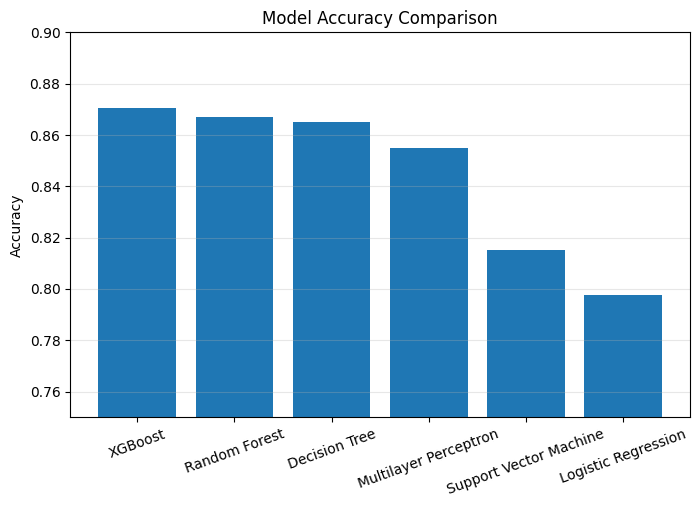

In [41]:
comparisonTableSorted = comparisonTable.sort_values(
    by="Accuracy",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.bar(
    comparisonTableSorted["Model"],
    comparisonTableSorted["Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.ylim(0.75,0.90)
plt.grid(axis="y", alpha=0.3)

plt.show()

### Interpretation

XGBoost achieved the highest accuracy (87.05%), followed closely by Random Forest (86.70%) and Decision Tree (86.50%).

Multilayer Perceptron also achieved competitive performance, while Support Vector Machine and Logistic Regression obtained lower accuracy.

Overall, XGBoost achieved the best classification accuracy on this dataset.


**F1 Score Comparison:**

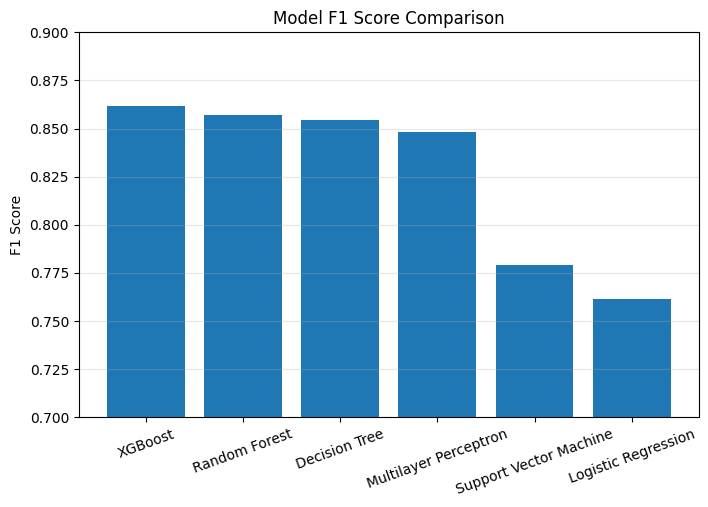

In [42]:
plt.figure(figsize=(8,5))

comparisonTableSorted = comparisonTable.sort_values(
    by="F1 Score",
    ascending=False
)

plt.bar(
    comparisonTableSorted["Model"],
    comparisonTableSorted["F1 Score"]
)

plt.ylabel("F1 Score")

plt.title("Model F1 Score Comparison")

plt.xticks(rotation=20)

plt.ylim(0.70,0.90)

plt.grid(axis="y", alpha=0.3)

plt.show()

### **Interpretation**

XGBoost achieved the highest F1 score (86.19%), followed closely by Random Forest (85.73%) and Decision Tree (85.47%).

These models achieved the best balance between precision and recall.

Support Vector Machine and Logistic Regression had lower F1 scores because their recall was lower, even though they achieved high precision.

Overall, XGBoost provided the best balance between correctly detecting phishing websites and minimizing false predictions.

**Recall Comparison:**

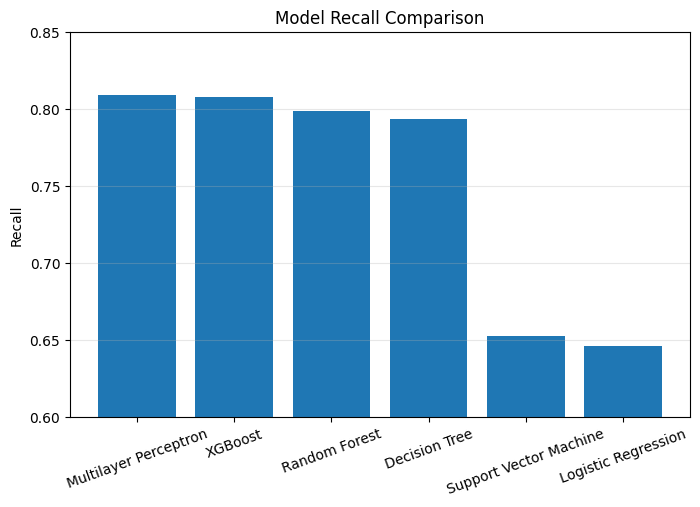

In [43]:
plt.figure(figsize=(8,5))

comparisonTableSorted = comparisonTable.sort_values(
    by="Recall",
    ascending=False
)

plt.bar(
    comparisonTableSorted["Model"],
    comparisonTableSorted["Recall"]
)

plt.ylabel("Recall")

plt.title("Model Recall Comparison")

plt.xticks(rotation=20)

plt.ylim(0.60,0.85)

plt.grid(axis="y", alpha=0.3)

plt.show()

### **Interpretation**

Recall is very important in phishing website detection because it measures how many phishing websites were correctly detected.

Multilayer Perceptron achieved the highest recall (80.90%), followed very closely by XGBoost (80.80%) and Random Forest (79.90%).

Logistic Regression and Support Vector Machine had much lower recall, meaning they missed more phishing websites.

Overall, XGBoost and MLP were the strongest models in detecting phishing websites, while XGBoost still achieved the best overall balance across all metrics.

**Precision Comparison:**

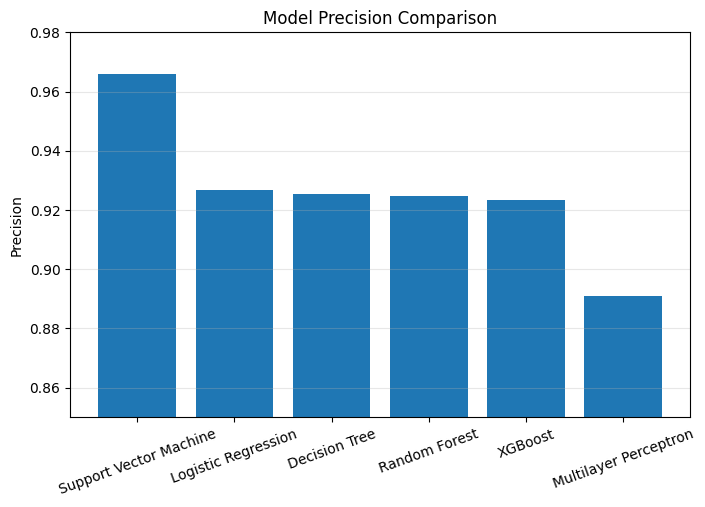

In [44]:
plt.figure(figsize=(8,5))

comparisonTableSorted = comparisonTable.sort_values(
    by="Precision",
    ascending=False
)

plt.bar(
    comparisonTableSorted["Model"],
    comparisonTableSorted["Precision"]
)

plt.ylabel("Precision")

plt.title("Model Precision Comparison")

plt.xticks(rotation=20)

plt.ylim(0.85,0.98)

plt.grid(axis="y", alpha=0.3)

plt.show()

### **Interpretation**

Support Vector Machine achieved the highest precision (96.60%), followed by Logistic Regression (92.68%), Decision Tree (92.54%), Random Forest (92.48%), and XGBoost (92.34%).

A high precision means that when the model predicts a website as phishing, it is usually correct.

Although SVM achieved the highest precision, its recall was much lower than the tree-based models, meaning it missed many phishing websites.

Overall, XGBoost and Random Forest provided a better balance between precision and recall, making them more suitable for phishing detection.

## Additional Evaluation Metrics

To provide a more comprehensive evaluation of the classifiers, additional performance metrics and analyses were performed.

Besides Accuracy, Precision, Recall, and F1-score, the models were also evaluated using:

- Matthews Correlation Coefficient (MCC)
- F2-score
- ROC-AUC
- PR-AUC
- Threshold Analysis

These metrics provide additional insight into classifier performance, ranking ability, and the trade-off between detecting phishing websites and reducing false alarms.

**ROC Curve Comparison:**

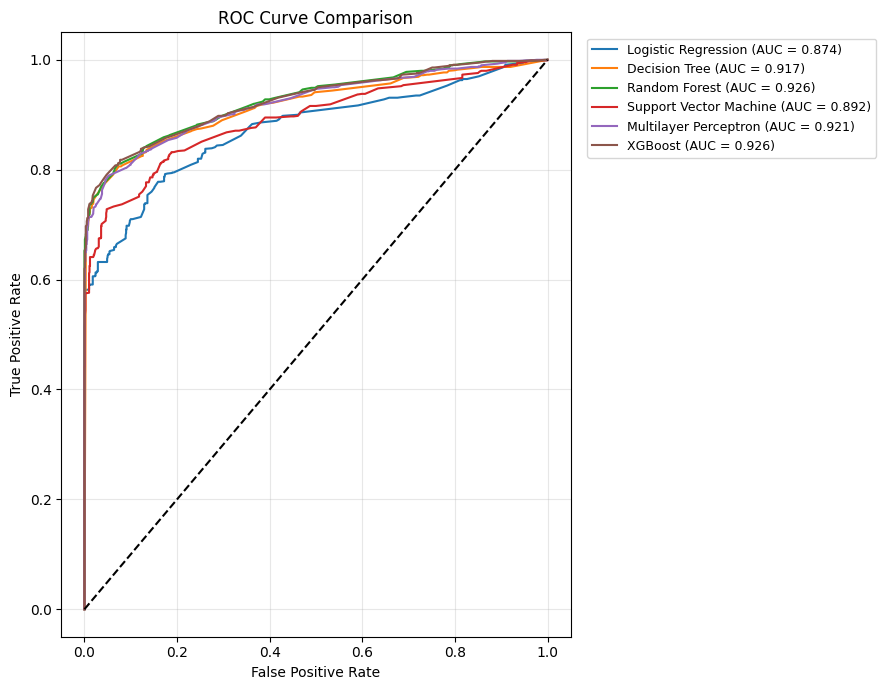

In [47]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

plt.figure(figsize=(9,7))

models = [
    ("Logistic Regression", logisticScores),
    ("Decision Tree", decisionTreeScores),
    ("Random Forest", randomForestScores),
    ("Support Vector Machine", svmScores),
    ("Multilayer Perceptron", mlpScores),
    ("XGBoost", xgboostScores)
]

for modelName, scores in models:

    fpr, tpr, _ = roc_curve(
        yTest,
        scores
    )

    rocAuc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{modelName} (AUC = {rocAuc:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

**Precision-Recall Curve Comparison:**

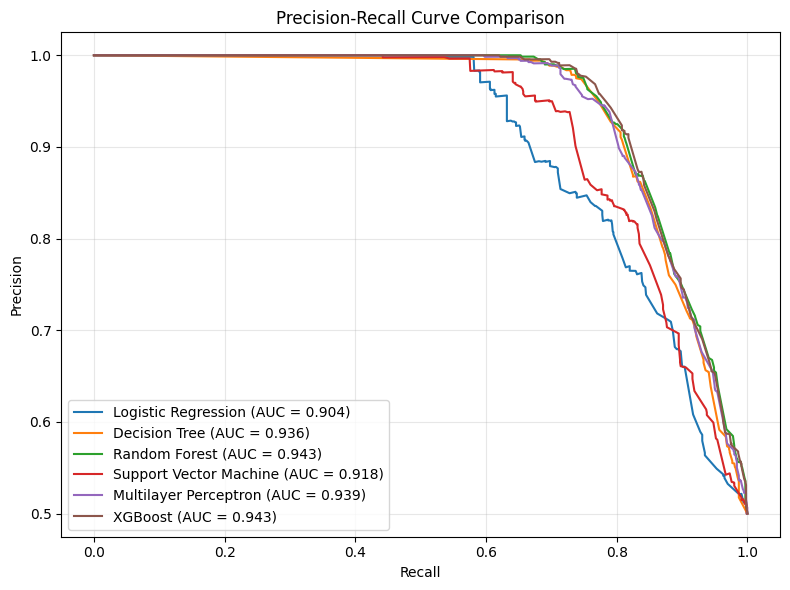

In [48]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,6))

for modelName, scores in models:

    precision, recall, _ = precision_recall_curve(
        yTest,
        scores
    )

    prAuc = average_precision_score(
        yTest,
        scores
    )

    plt.plot(
        recall,
        precision,
        label=f"{modelName} (AUC = {prAuc:.3f})"
    )

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve Comparison")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

The Precision-Recall curves further confirm the superiority of XGBoost and Random Forest. These models maintain high precision even at high recall values, indicating a better balance between detecting phishing websites and limiting false alarms

**Precision vs Threshold:**

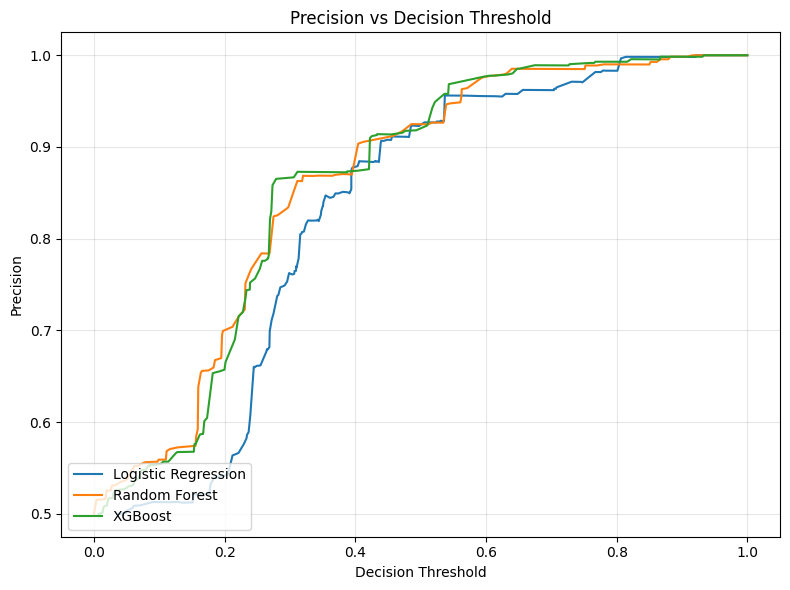

In [51]:
plt.figure(figsize=(8,6))

thresholdModels = [
    ("Logistic Regression", logisticScores),
    ("Random Forest", randomForestScores),
    ("XGBoost", xgboostScores)
]

for modelName, scores in thresholdModels:

    precision, recall, thresholds = precision_recall_curve(
        yTest,
        scores
    )

    plt.plot(
        thresholds,
        precision[:-1],
        label=modelName
    )

plt.xlabel("Decision Threshold")
plt.ylabel("Precision")
plt.title("Precision vs Decision Threshold")

plt.legend(
    loc="lower left"
)

plt.grid(alpha=0.3)

plt.tight_layout()


plt.show()

**Recall vs Threshold:**

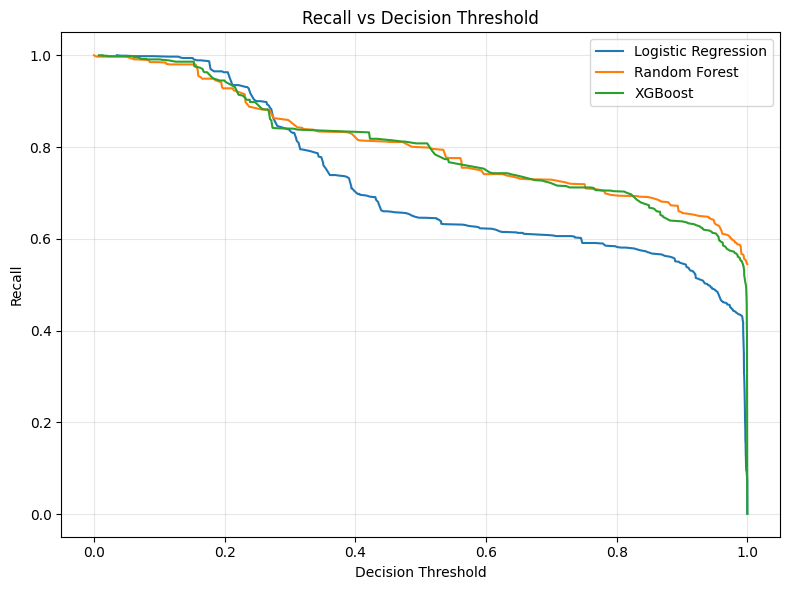

In [52]:
plt.figure(figsize=(8,6))

for modelName, scores in thresholdModels:

    precision, recall, thresholds = precision_recall_curve(
        yTest,
        scores
    )

    plt.plot(
        thresholds,
        recall[:-1],
        label=modelName
    )

plt.xlabel("Decision Threshold")
plt.ylabel("Recall")
plt.title("Recall vs Decision Threshold")

plt.legend(
    loc="upper right"
)

plt.grid(alpha=0.3)

plt.tight_layout()


plt.show()

### Interpretation

The threshold analysis illustrates the trade-off between precision and recall.

As the decision threshold increases, precision improves while recall decreases. XGBoost and Random Forest maintain a better balance between these two measures across a wide range of thresholds, while Logistic Regression loses recall more rapidly.

These results further support selecting XGBoost as the preferred model for phishing website detection.

## **Final Discussion**

Six machine learning models were evaluated for phishing website detection using multiple evaluation metrics, including Accuracy, Precision, Recall, F1-score, F2-score, Matthews Correlation Coefficient (MCC), ROC-AUC, and PR-AUC.

The results consistently show that XGBoost achieved the best overall performance. It obtained the highest accuracy (87.05%), the highest F1-score (86.19%), and also achieved the highest MCC and PR-AUC values. Its ROC-AUC was also among the highest, indicating excellent classification performance and strong ranking ability.

Random Forest performed almost as well as XGBoost across all evaluation metrics. It achieved very similar MCC, ROC-AUC, and PR-AUC values, showing that both ensemble methods are highly effective for phishing website detection. Decision Tree also performed well but was slightly less robust than Random Forest because a single tree is more prone to overfitting.

Support Vector Machine achieved the highest precision, meaning that most websites classified as phishing were actually phishing. However, its recall was much lower than the other models, indicating that it missed more phishing websites.

Logistic Regression showed the lowest overall performance because it is a simple linear model and could not fully capture the complex relationships between the extracted website features.

The additional evaluation metrics further confirmed the superiority of XGBoost and Random Forest. Their high MCC values indicate better overall classification quality, while their ROC-AUC and PR-AUC scores demonstrate stronger ranking performance across different decision thresholds.

The threshold analysis also showed the trade-off between precision and recall. As the decision threshold increased, precision improved while recall decreased. XGBoost and Random Forest maintained a better balance between these two measures across a wide range of thresholds, making them more suitable for phishing detection where both high detection capability and low false alarm rates are important.

Overall, the tree-based ensemble models, especially XGBoost and Random Forest, were the most effective models for this dataset because they consistently achieved the best balance between detecting phishing websites and reducing false predictions across all evaluation metrics.

Although XGBoost achieved the best performance on this dataset, additional validation on larger and more realistic datasets would still be necessary before deploying the model in a real cybersecurity system.

## **Conclusion**

This project evaluated six machine learning models for phishing website detection using the same dataset and evaluation protocol.

The models were evaluated using multiple performance metrics, including Accuracy, Precision, Recall, F1-score, F2-score, Matthews Correlation Coefficient (MCC), ROC-AUC, and PR-AUC. In addition, ROC curves, Precision-Recall curves, and threshold analysis were used to provide a more comprehensive evaluation of the classifiers.

The results show that advanced machine learning models generally outperformed simpler models. Among all evaluated models, XGBoost achieved the best overall performance, with the highest accuracy, F1-score, MCC, and PR-AUC, while maintaining high precision and recall. Random Forest achieved very similar results across all evaluation metrics, making it another strong candidate for phishing website detection.

Decision Tree also performed well but was slightly less robust than Random Forest. Multilayer Perceptron achieved competitive performance, while Support Vector Machine achieved the highest precision but lower recall, indicating that it missed more phishing websites. Logistic Regression showed the weakest overall performance because of its limited ability to model complex relationships between the extracted features.

The additional evaluation metrics and threshold analysis further confirmed that XGBoost and Random Forest provide the best balance between detecting phishing websites and minimizing false alarms. Overall, the results demonstrate that tree-based ensemble models are the most suitable approach for this phishing website detection dataset.

## **Critical Evaluation of the Original Project**



The original project demonstrates that machine learning can effectively detect phishing websites using handcrafted URL and website features. The results obtained in this project support this conclusion, as all evaluated models achieved good classification performance.

However, extending the evaluation with additional models provided new insights. Besides the original models, this project also evaluated Support Vector Machine, Multilayer Perceptron, and XGBoost. Among all evaluated models, XGBoost achieved the best overall performance, showing that a broader comparison can lead to different conclusions.

Another important limitation is the dataset itself. It contains an equal number of phishing and legitimate websites (5,000 each), which does not reflect real-world phishing prevalence. In practice, phishing websites are much less common, so evaluation on a perfectly balanced dataset may overestimate real-world performance.

Overall, the original project provides a strong baseline for phishing website detection. However, a broader comparison of machine learning models together with a discussion of the dataset limitations provides a more complete and critical evaluation of the proposed approach.

Future work could evaluate these models on larger and naturally imbalanced phishing datasets to better reflect real-world deployment conditions.